Amazon Customer Reviews

Fase 1. Importación de Librerías 

En esta sección se importan las librerías necesarias para la conexión a la base de datos, el procesamiento de la información, el análisis estadístico, entrenamiento y evaluación de un modelo de Machine Learning

In [340]:
! pip install pandas numpy matplotlib pyodbc
! pip install textblob


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [341]:
import pandas as pd
import numpy as np
import pyodbc

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from textblob import TextBlob




Fase 2. Conexión a SQL Server

Se establece la conexión con la base de datos SQL Server, desarrollada por la Ingeniera de Datos del equipo para acceder a la información de la Capa Plata. 

In [342]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=AmazonReviews_Plata;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

Fase 3. Lectura de la Capa Plata 

Se cargaron cuatro tablas principales, realizando un análisis de sus dimensiones, tipos de datos y una vista previa de sus primeros registros:

In [343]:
df_clientes = pd.read_sql("SELECT * FROM plata.clientes",conn)


C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\1061270435.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_clientes = pd.read_sql("SELECT * FROM plata.clientes",conn)


In [344]:
df_clientes.head(10)

,customer_id
0,100000
1,10000013
2,10000027
3,10000030
4,10000031
5,10000037
6,10000040
7,10000044
8,10000049
9,10000059


In [345]:
df_clientes.shape

(5796896, 1)

In [346]:
df_clientes.dtypes

customer_id    str
dtype: object

In [347]:
df_clientes["customer_id"].unique()

<StringArray>
[  '100000', '10000013', '10000027', '10000030', '10000031', '10000037',
 '10000040', '10000044', '10000049', '10000059',
 ...
  '9999960',  '9999961',  '9999963',  '9999978',  '9999979',  '9999980',
  '9999984',  '9999985',  '9999987',  '9999998']
Length: 5796896, dtype: str

El df_cliente primero muestra 10 datos de la tabla, cuenta con 5796896 filas y 1 columna y el tipo de texto seria object. El customer_id se encuentra como valor único. 

In [348]:
df_productos = pd.read_sql("SELECT * FROM plata.productos",conn)

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\3186617615.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_productos = pd.read_sql("SELECT * FROM plata.productos",conn)


In [349]:
df_productos.head(10)

,product_id,product_parent,product_title,product_category,marca
0,0001046314,680358721,A Woman of Substance,Books,Sin marca identificada
1,0001712071,729164591,"Mr. Brown Can Moo, Can You? (Beginner Series)",Books,Sin marca identificada
2,0001857010,915528414,"The Lion, the Witch and the Wardrobe (The Chro...",Books,Sin marca identificada
3,0001939777,915528414,"The Lion, the Witch and the Wardrobe (The Chro...",Books,Sin marca identificada
4,0002005549,245555180,PREY.,Books,Sin marca identificada
5,0002008599,82188916,The Monk Who Sold His Ferrari: A Remarkable St...,Books,Sin marca identificada
6,0002051850,896923,For Whom the Bell Tolls,Books,Sin marca identificada
7,0002171856,275786765,The Sas Survival Handbook,Books,Sin marca identificada
8,0002180618,986630902,The One Minute Manager,Books,Sin marca identificada
9,0002197286,978255319,Collins Bird Guide: The Most Complete Field Gu...,Books,Sin marca identificada


In [350]:
df_productos.shape

(272578, 5)

In [351]:
df_productos.dtypes

product_id          str
product_parent      str
product_title       str
product_category    str
marca               str
dtype: object

El df_productos primero muestra 10 datos de la tabla entre ellos el titulo del producto y la categoria en este caso se indican libro sin marca identificada, cuenta con 272578 filas y 5 columnas y el tipo de texto seria object. 

In [352]:
df_reviews = pd.read_sql( "SELECT TOP 100000 * FROM plata.reviews", conn)

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\3971865951.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reviews = pd.read_sql( "SELECT TOP 100000 * FROM plata.reviews", conn)


In [353]:
df_reviews.head(10)

,review_id,customer_id,product_id,marketplace,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_date,categoria_origen
0,R10000WAG70YS2,6343669,B00FAPF5U0,US,5,0,0,False,True,2014-01-19,multilingue
1,R10000WMGXS51T,28053693,B00CZDT30S,US,5,1,1,False,True,2015-08-28,electronics
2,R10001CO1GYGD2,16603554,B004EPYZQC,US,5,0,0,False,True,2015-06-28,multilingue
3,R10001L4QTCA84,31242940,B00HG1L334,US,5,0,0,False,True,2015-03-14,electronics
4,R10001OP8YVPFD,52564468,0316666343,US,5,0,0,False,False,2004-11-05,multilingue
5,R10002H1T5W9ZT,31059135,B009UX2YAC,US,4,0,0,False,True,2015-08-09,multilingue
6,R10002LVDMO0UX,10122133,B000BVMAJ2,US,5,0,0,False,True,2015-04-18,multilingue
7,R10003HA48BDHT,23830040,B00B2V66VS,US,5,9,10,False,True,2013-01-26,multilingue
8,R10003OLR2P5UE,47076757,B000MMWT9Q,US,3,0,0,False,False,2009-12-07,electronics
9,R10003UGGTHTDR,16265036,B00HGJ18C2,US,4,0,0,False,True,2014-08-05,multilingue


In [354]:
df_reviews.shape

(100000, 11)

In [355]:
df_reviews.dtypes 

review_id               str
customer_id             str
product_id              str
marketplace             str
star_rating           int64
helpful_votes         int64
total_votes           int64
vine                   bool
verified_purchase      bool
review_date          object
categoria_origen        str
dtype: object

El df_reviews primero muestra 10 datos de la tabla de los cuales se indican donde se realizo la transacción y las reseñas, la calificación del clientes, el número de usuarios que votaron, el total de votos, un indicador verdadero y falso del cual señala si la reseña proviene del programa de Amazon, si se realizo una compra por parte de la persona que hizo la reseña, las fechas exactas que público y la categoría del producto evaluado. En lo que fue reviews se decidio trabajar con una muestra ya que contiene gran cantidad de datos y si vuelve muy lento el análisis. Se presenta una muestra de 100000 filas y 11 columnas.

In [356]:
df_reviews_texto = pd.read_sql("SELECT TOP 100000 * FROM plata.reviews_texto", conn)

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\1521776271.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reviews_texto = pd.read_sql("SELECT TOP 100000 * FROM plata.reviews_texto", conn)


In [357]:
df_reviews_texto['body_length_chars'] = df_reviews_texto['review_body'].apply(len)
df_reviews_texto['body_length_words'] = df_reviews_texto['review_body'].apply(lambda x: len(x.split()))
df_reviews_texto['headline_length_words'] = df_reviews_texto['review_headline'].apply(lambda x: len(x.split()))

In [358]:
df_reviews_texto.head(10)

,review_id,review_headline,review_body,tiene_comentario,body_length_chars,body_length_words,headline_length_words
0,R10000WAG70YS2,candy crush,I love it. its enjoyable and I cant stop playi...,1,128,27,2
1,R10000WMGXS51T,Great little emergency radio,Great little emergency radio. Very good recep...,1,128,20,4
2,R10001CO1GYGD2,Five Stars,Great item fast shipping and it was as describ...,1,84,15,2
3,R10001L4QTCA84,Fits in the S3 Cruzuerlite case,"Lives up to its claim, and really does fit bul...",1,220,41,6
4,R10001OP8YVPFD,the lovely pages,"Like other reviewers, I found that I literally...",1,961,170,3
5,R10002H1T5W9ZT,Four Stars,It s ok,1,7,3,2
6,R10002LVDMO0UX,Five Stars,works fine,1,10,2,2
7,R10003HA48BDHT,addictive,This game is very addictive everything is swee...,1,130,23,1
8,R10003OLR2P5UE,"Amazing, but Do Not Last",I've gone through three pairs of these in the ...,1,1271,230,5
9,R10003UGGTHTDR,Four Stars,ok escape,1,9,2,2


In [359]:
df_reviews_texto.shape

(100000, 7)

In [360]:
df_reviews_texto.dtypes

review_id                  str
review_headline            str
review_body                str
tiene_comentario         int64
body_length_chars        int64
body_length_words        int64
headline_length_words    int64
dtype: object

En lo que fue el df_reviews_texto tambien se decidio trabajar con una muestra para hacer un análisis mas rapido y menos pesado por la gran cantidad de datos que contiene. Se observa información sobre la experiencia del cliente, análisis de sentimiento sobre su experiencia en la compra y si el cliente dejó un comentario tomando en cuenta la longitud o tamaño del cuerpo de la reseña. Se decidio trabajar con 100000 filas y 7 columnas. 

In [361]:
print("Nulos en df_clientes:\n", df_clientes.isnull().sum())
print("\nNulos en df_productos:\n", df_productos.isnull().sum())
print("\nNulos en df_reviews:\n", df_reviews.isnull().sum())
print("\nNulos en df_reviews_texto:\n", df_reviews_texto.isnull().sum())

Nulos en df_clientes:
 customer_id    0
dtype: int64

Nulos en df_productos:
 product_id          0
product_parent      0
product_title       0
product_category    0
marca               0
dtype: int64

Nulos en df_reviews:
 review_id            0
customer_id          0
product_id           0
marketplace          0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_date          0
categoria_origen     0
dtype: int64

Nulos en df_reviews_texto:
 review_id                0
review_headline          0
review_body              0
tiene_comentario         0
body_length_chars        0
body_length_words        0
headline_length_words    0
dtype: int64


Se confirmo la ausencia de valores nulos, lo cual se puede comprobar que la ingeniera de datos realizo correctamente el proceso de limpieza en la capa Plata de SQL resultando exitoso. 

Fase 4. Estadistica Descriptiva 

4.1 Clientes 

In [362]:
print(df_clientes.describe(include="object"))
print("Valores únicos:", df_clientes.nunique())

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\2573761061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_clientes.describe(include="object"))


       customer_id
count      5796896
unique     5796896
top         100000
freq             1
Valores únicos: customer_id    5796896
dtype: int64


En df_clientes como valor único solo presenta el ID de forma categórica alrededor de 5796896 registos tanto en fila como valor único, lo que nos indica que no hay duplicados y que cada fila representa un cliente distinto. 


4.2 Productos 

In [363]:
print(df_productos.describe(include="object"))
print(df_productos["product_category"].value_counts().head(10))

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\3204916994.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_productos.describe(include="object"))


        product_id product_parent product_title product_category  \
count       272578         272578        272578           272578   
unique      272578         182234        220141               38   
top     0001046314      569473707  Frankenstein      Electronics   
freq             1            505           128           185848   

                         marca  
count                   272578  
unique                     233  
top     Sin marca identificada  
freq                    216668  
product_category
Electronics               185848
Music                      20586
Books                      19976
Video DVD                  15602
Digital_Video_Download     11167
Digital_Music_Purchase      6423
Digital_Ebook_Purchase      4984
Video                       2796
Mobile_Apps                 1326
Toys                        1162
Name: count, dtype: int64


El df_product contiene 272578 registros todas tipo texto, no existe valores duplicados en product_id, en el product_parents se encontro con 182234 valores únicos lo que corresponden a diferentes ediciones o variantes de un mismo producto base,cuenta con el valor más repetido de 505 productos. En product_title se observa que existen 220141 valores únicos que comparten el mismo nombre/título pero contiene diferente edición en este caso el nombre que más se repite es Frankenstein con 128 veces y en product_category se puede visualizar que el producto mas predominante de todos es Electronics con una frecuencia de 185848. 

4.3 Reviews 

In [364]:
resumen = df_reviews[["star_rating", "helpful_votes", "total_votes"]].agg(
    ["mean", "median", "std", "var", "min", "max"]
)
resumen.loc["mode"] = df_reviews[["star_rating", "helpful_votes", "total_votes"]].mode().iloc[0]
print(resumen)

        star_rating  helpful_votes  total_votes
mean       4.220400       1.805640     2.757620
median     5.000000       0.000000     0.000000
std        1.232712      14.881882    17.848021
var        1.519579     221.470419   318.551837
min        1.000000       0.000000     0.000000
max        5.000000    1500.000000  1715.000000
mode       5.000000       0.000000     0.000000


In [365]:
print(df_reviews[["verified_purchase", "vine", "categoria_origen"]].describe(include="object"))

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\2015772698.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_reviews[["verified_purchase", "vine", "categoria_origen"]].describe(include="object"))


       categoria_origen
count            100000
unique                2
top         multilingue
freq              69119


En df_reviews si aplica estadistica númerica a diferencia de las demás que han sido mas texto/categoría. En el primer bloque podemos ver la parte estadistica númerica, en donde la calificación por estrellas se mantiene consistente, es decir al tener un promedio de 4.22, una mediana de 5 y un moda de 5 indica que los clientes califican con la puntuación maxima de 5 y los que califican entre 1 o 2 estrellas son los que bajan ese promedio de 4.22. En lo que sería votos útiles y total de votos se percibe que la mediana y la moda tienen un 0, lo que indica que la mayoria no recibe un voto de utilidad por parte de los consumidores pero si vemos el promedio es mayor a 0 lo que nos dice que hay una gran cantidad de votos y encontramos una desviación estandar mayor que la media lo cual consiste mucho en lo que más adelante se va a ver en la Detección de Patrones Anómalos. 

4.4 Reviews_Texto 

In [366]:
resumen_texto = df_reviews_texto[["body_length_chars", "body_length_words", "headline_length_words"]].agg(
    ["mean", "median", "std", "var", "min", "max"]
)
resumen_texto.loc["mode"] = df_reviews_texto[["body_length_chars", "body_length_words", "headline_length_words"]].mode().iloc[0]
print(resumen_texto)

print(df_reviews_texto["tiene_comentario"].value_counts())

        body_length_chars  body_length_words  headline_length_words
mean           383.687150          69.212140                4.02848
median         162.000000          30.000000                3.00000
std            764.452196         132.738881                3.18064
var         584387.160666       17619.610473               10.11647
min              1.000000           1.000000                1.00000
max          40231.000000        6564.000000               35.00000
mode            10.000000          20.000000                2.00000
tiene_comentario
1    99985
0       15
Name: count, dtype: int64


En longitud del cuerpo en caracteres y longitud del cuerpo en palabras se encuentra que el promedio es mayor a la mediana en donde se indica que la mayoria de reseñas tienen una longitud de texto breve pero hay pocas que tienen reseñas extensas con 40231 caracteres y 6564 palabras. Mientras que la longitud del tiular muestra una coherencia en base a su promedio 4.02 y desviación estandar 3.18 sobre la reseñas de los titulos y en si tiene comentario muestra una gran cantidad de comentarios 99985 sobre una muestra de 100000 lo cual es bueno porque nos permite un mayor análisis de sentimiento. 

Conclusion sobre la Estadistica Descriptiva 

Respecto a los Clientes, se confirmó que no existen registros duplicados, lo que garantiza que cada cliente está representado una única vez en la base de datos.Con base al estudio sobre productos, la categoria Electronica destaca como la mas predominante por el consumidor. Asimismo se refleja una alta satisfacción de los clientes lo cual se determinó en la calificación estrella en donde hubieron calificaciones de 1 o 2 estrellas que bajaron el promedio hacia un 4.22, lo cual indica que predomina la calificación máxima, aunque persiste un sector crítico de usuarios. De igual manera, se comprende que la mayoría de las reseñas no recibe votos de utilidad, mientras que un pequeño grupo concentra una cantidad desproporcionada de votos, posiblemente por tratarse de reseñas destacadas o promovidas por Amazon. Hay muchas reseñas breves como por ejemplo: "Esta bien" "Funciona bien" "Escape correcto" y pocas reseñas extensas con gran cantidad de caracteres y palabras. Ademas existe una gran cantidad de comentarios tomados de una muestra lo cual es bueno porque se puede hacer un modelo de Machine Learning más completo sobre el análisis de sentimiento. 

Fase 5. Ingeniería de Características

En esta parte se generan variables relevantes con el fin de alimentar mejor los modelos estadísticos y de Machine Learning. 

5.1 Características numéricas y de comportamiento

In [367]:
df_reviews['verified_numeric'] = df_reviews['verified_purchase'].astype(int)
df_reviews['vine_numeric'] = df_reviews['vine'].apply(lambda x: 1 if str(x).upper() in ['Y', 'TRUE', '1'] else 0)
df_reviews['helpful_ratio'] = np.where(
    df_reviews['total_votes'] > 0, 
    df_reviews['helpful_votes'] / df_reviews['total_votes'], 
    0.0
)
print(df_reviews[['star_rating', 'verified_numeric', 'helpful_votes', 'total_votes', 'helpful_ratio']].head())

   star_rating  verified_numeric  helpful_votes  total_votes  helpful_ratio
0            5                 1              0            0            0.0
1            5                 1              1            1            1.0
2            5                 1              0            0            0.0
3            5                 1              0            0            0.0
4            5                 0              0            0            0.0


El indicador de compra verificada se transformó a un formato numérico verified_numeric: 1 para compras reales confirmadas por Amazon y 0 en caso contrario. Esto permite medir si los clientes con compras verificadas reciben o dan valoraciones distintas a los que no tienen compra verificada. Además, se calculó qué tan útil fue considerada una reseña dentro de la comunidad mediante helpful_ratio, un valor que va de 0.0 a 1.0 no solo esos dos extremos, sino cualquier proporción intermedia, donde valores cercanos a 1.0 indican que la mayoría de los votos consideraron la reseña útil, y valores cercanos a 0.0 indican lo contrario.

5.2 Características de texto

In [368]:
df_reviews_texto['body_length_chars'] = df_reviews_texto['review_body'].apply(len)
df_reviews_texto['body_length_words'] = df_reviews_texto['review_body'].apply(lambda x: len(x.split()))
df_reviews_texto['headline_length_words'] = df_reviews_texto['review_headline'].apply(lambda x: len(x.split()))
print(df_reviews_texto[['tiene_comentario', 'body_length_chars', 'body_length_words', 'headline_length_words']].head())


   tiene_comentario  body_length_chars  body_length_words  \
0                 1                128                 27   
1                 1                128                 20   
2                 1                 84                 15   
3                 1                220                 41   
4                 1                961                170   

   headline_length_words  
0                      2  
1                      4  
2                      2  
3                      6  
4                      3  


Esta variables nos ayuda a saber sobre la longitud del texto en reseña, tanto el tamaño del cuerpo en caracteres como en números. Lo cual nos permite determinar que tan extenso o no fue el comentario brindado como parte del análisis de sentimiento. 

5.3 Reputación de Marcas por Categoría de Producto

In [369]:
df_reviews_productos = df_reviews.merge(
    df_productos,
    on='product_id',
    how='inner'
)

print(df_reviews_productos.shape)
print(df_reviews_productos.columns.tolist())

(100000, 18)
['review_id', 'customer_id', 'product_id', 'marketplace', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_date', 'categoria_origen', 'verified_numeric', 'vine_numeric', 'helpful_ratio', 'product_parent', 'product_title', 'product_category', 'marca']


In [370]:
reputacion_marca_categoria = (
    df_reviews_productos
    .groupby(['product_category', 'marca'])
    .agg(
        promedio_calificacion=('star_rating', 'mean'),
        total_reseñas=('review_id', 'count')
    )
    .reset_index()
)


reputacion_marca_categoria = reputacion_marca_categoria[
    reputacion_marca_categoria['marca'] != 'Sin marca identificada'
]


reputacion_filtrada = reputacion_marca_categoria[reputacion_marca_categoria['total_reseñas'] >= 10]

mejor_marca_por_categoria = (
    reputacion_filtrada
    .loc[reputacion_filtrada.groupby('product_category')['promedio_calificacion'].idxmax()]
    [['product_category', 'marca', 'total_reseñas', 'promedio_calificacion']]
    .sort_values('promedio_calificacion', ascending=False)
    .reset_index(drop=True)
)

print(mejor_marca_por_categoria.head(10))

      product_category         marca  total_reseñas  promedio_calificacion
0          Electronics          TiVo             11               5.000000
1  Musical Instruments          Sony             21               4.904762
2                Books          LEGO             10               4.900000
3               Camera         Nikon             18               4.833333
4            Video DVD          LEGO             14               4.714286
5                   PC         Intel             16               4.687500
6             Wireless   Plantronics             16               4.625000
7              Watches       Invicta             17               4.529412
8                 Baby  Fisher-Price             14               4.500000
9                 Toys          LEGO            123               4.479675


En esta parte es interesante observar que entre el top de categorías de productos que se ve más adelante el mayor en volumen es Electronica (Parte 6.5).Y en este  estudio de reputación de marca por categoría de producto con un top 10 Electronicas es la que tiene mejor promedio 5.00 con la marca TiVo con un total de 11 reseñas, con un segundo lugar de Musical Instruments con la marca Sony con un promedio de 4.90 y total de reseñas de 21. Es importante mencionar tambien que estos resultados reflejan las marcas de cada categoria, no de su categoria en general. 

5.4 Detección de Patrones anómalas 

In [371]:
umbral_extremo_votos = df_reviews['total_votes'].quantile(0.995)
df_reviews['es_voto_anomalo'] = df_reviews['total_votes'] > umbral_extremo_votos

print(f"Umbral de votos totales para considerar anomalía (P99.5): {umbral_extremo_votos}")
print(f"Total de reseñas marcadas con comportamiento de votación anómalo: {df_reviews['es_voto_anomalo'].sum()}")

Umbral de votos totales para considerar anomalía (P99.5): 63.00500000000466
Total de reseñas marcadas con comportamiento de votación anómalo: 500


En esta variable se busca anomalías en reseñas que acumulan una gran cantidad de votos lo cual es importante para evitar que nos alteren el análisis de sentimientos.Por lo que se crea en total_votes como (true/false).Si el total de votos supera el percentil de 99.5 marca como un voto anómalo (true) de lo contrario se mantiene como uno normal (false), eso quiere decir que el percentil 99.5 en 63 significa que el 99.5% de las reseñas tienen 63 votos o menos,si se recibi mas de ahí se indica como un comportamiento fuera de lo normal. Y de los 100000 registros de la muestra 500 reseñas superaron esa cantidad de 63 votos, lo que lo convierte en un resultado atípico. 

5.5 Detección de calificaciones anómalas

In [372]:
df_reviews_productos['promedio_categoria'] = df_reviews_productos.groupby('product_category')['star_rating'].transform('mean')
df_reviews_productos['desviacion_categoria'] = df_reviews_productos.groupby('product_category')['star_rating'].transform('std')

df_reviews_productos['calificacion_anomala'] = (
    abs(df_reviews_productos['star_rating'] - df_reviews_productos['promedio_categoria']) 
    > 2 * df_reviews_productos['desviacion_categoria']
)

print(f"Calificaciones anómalas detectadas: {df_reviews_productos['calificacion_anomala'].sum()}")
print(f"Porcentaje del total: {df_reviews_productos['calificacion_anomala'].mean():.2%}")

Calificaciones anómalas detectadas: 8849
Porcentaje del total: 8.85%


En esta parte se detectan calificaciones anómalas comparando cada reseña contra el promedio y desviación por categoría. Se encontraron 8849 calificaciones anómalas lo que equivale al 8.85% del total lo cuál indica posibles falsas reseñas, errores en calificaciones o experiencias anormales.

Conclusión de la Ingenería de Características 

Las Características numéricas y de comportamiento nos ayudan a medir si los clientes con compras verificadas reciben o dan valoraciones distintas a los que no tienen compra verificada y en texto nos ayuda a ver que tan extenso o breve fue el comentario brindado por el cliente. Sobre la reputación de marcas por categoría de producto se indica el mayor promedio de marca en esa categoría de producto, es decir la reputación de la marca TiVo de la categoría Electronica es la más alta con 5.00 y con un total de 11 reseñas. 

También se realizo una Detección de Patrones Anómalas y de Calificación, esto ayudó analizar que de 500 reseñas (0.5%) con votos fuera de lo normal sean muy probablemente reseñas que Amazon destaca o promueve o bien las 8849 calificaciones "anormales"(8.85%)  que fueran por experiencias extrañas, falsas reseñas o un error humano a la hora de calificar. 

6.Análisis Exploratorio de Datos

En esta etapa se realizara un análisis explotario de Datos a traves de varias visualizaciones con el objetivo de comprender el comportamiento de las diferentes variables en estudio. Estos gráficos nos permiten entender cómo se distribuyen las variables antes de entrenar modelos. 

6.1 Histograma de Calificación Estrella 

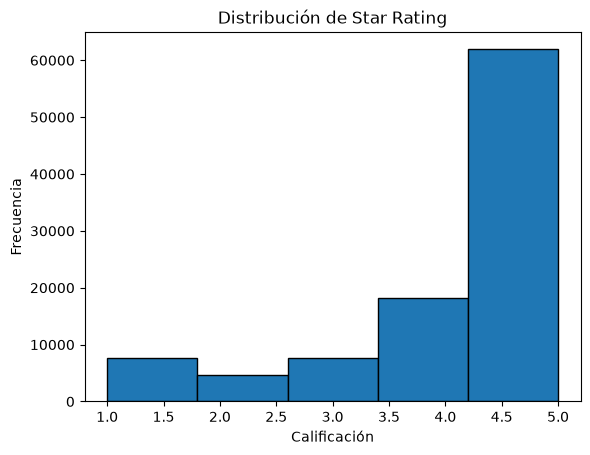

In [373]:
plt.hist(df_reviews["star_rating"], bins=5, edgecolor='black')
plt.title("Distribución de Star Rating")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()

Se observa que hay pocas calificaciones de 1 a 2 estrellas, la mayoria son muy buenas calififaciones de 5 estrellas, lo cual se inclina más a un balance de opiniones positivas. 

6.2 Histograma de votos útiles

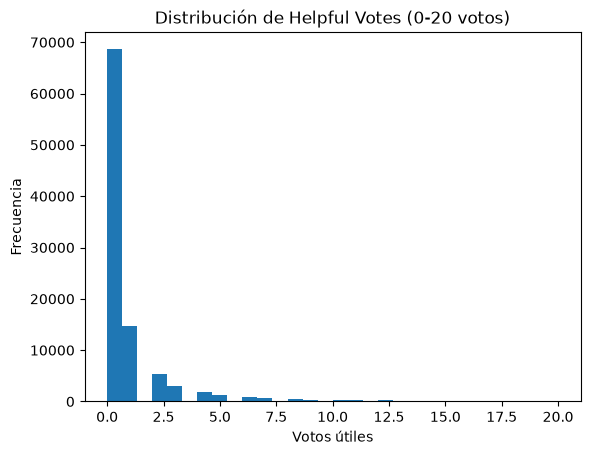

In [374]:
plt.hist(df_reviews["helpful_votes"], bins=30, range=(0, 20))
plt.title("Distribución de Helpful Votes (0-20 votos)")
plt.xlabel("Votos útiles")
plt.ylabel("Frecuencia")
plt.show()

Este grafico me ayuda análizar cuántos votos útiles recibe una reseña, se puede observar que la gran mayoria tiene 0 o pocos votos útiles, mientras que una minoria tienen muchos votos que se pueden ver en la más pequeñas. 

6.3 Histograma de Reseñas en Palabras

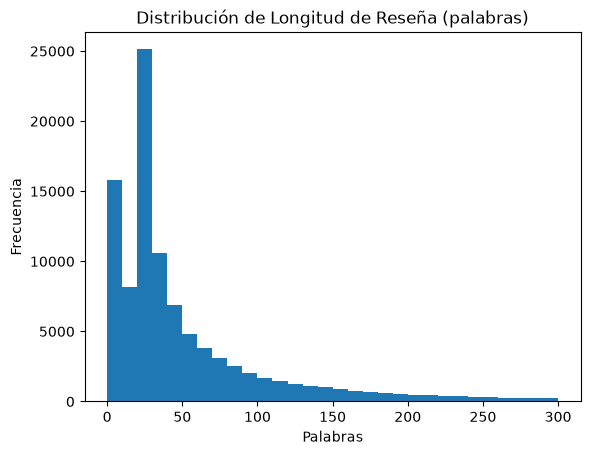

In [375]:
plt.hist(df_reviews_texto["body_length_words"], bins=30, range=(0, 300))
plt.title("Distribución de Longitud de Reseña (palabras)")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.show()

Se puede visualizar que la barra se inclina hacia el 20-30 de palabras, eso indica que los usuarios prefieren escribir comentarios breves pero puntuales para calificar el producto, mientras que la asímetria hacia la derecha señala cada vez menos frecuente los comentarios extensos con gran cantidad de palabras. 

6.4 Boxplots (para visualizar outliers)

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\2215760628.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_reviews["total_votes"], vert=True)


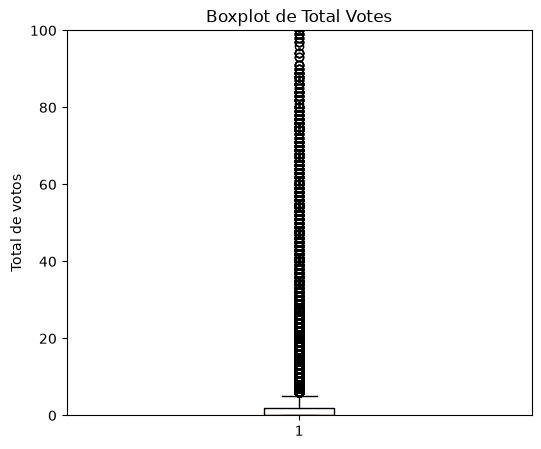

C:\Users\ganza\AppData\Local\Temp\ipykernel_18052\2215760628.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_reviews_texto["body_length_words"], vert=True)


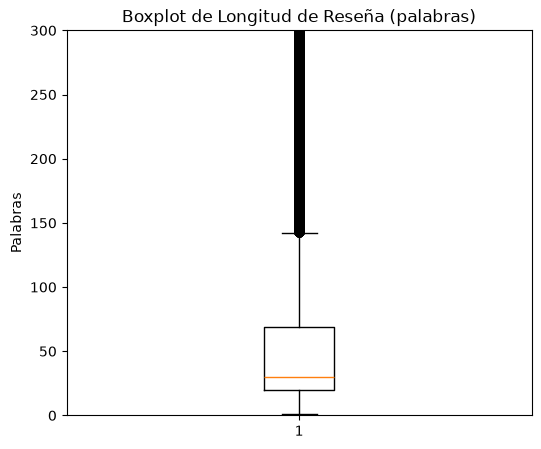

In [376]:
plt.figure(figsize=(6,5))
plt.boxplot(df_reviews["total_votes"], vert=True)
plt.title("Boxplot de Total Votes")
plt.ylabel("Total de votos")
plt.ylim(0, 100)  
plt.show()

plt.figure(figsize=(6,5))
plt.boxplot(df_reviews_texto["body_length_words"], vert=True)
plt.title("Boxplot de Longitud de Reseña (palabras)")
plt.ylabel("Palabras")
plt.ylim(0, 300)
plt.show()

En el primer Boxplot del Total de Votos se visualiza de esa manera porque la mayoria de reseñas no reciben votos ya que se ve la caja como de forma aplastada hasta el 0. Ademas la linea negra que se ve con puntos o círculos confirma la detección de valores atípicos que tambien se vio en la detección de Patrones Anómalos. 

Ahora bien sobre el Boxplot de Longitud de Reseña se confirma la información que se observo antes en el histograma, se ve donde se concentra mas los comentarios breves entre el 20-30 y la linea central que se ve en la caja lo confirma, el bigote muestra a ese grupo pequeño de reseñas extensas. 

6.5 Distribución por categoría de producto

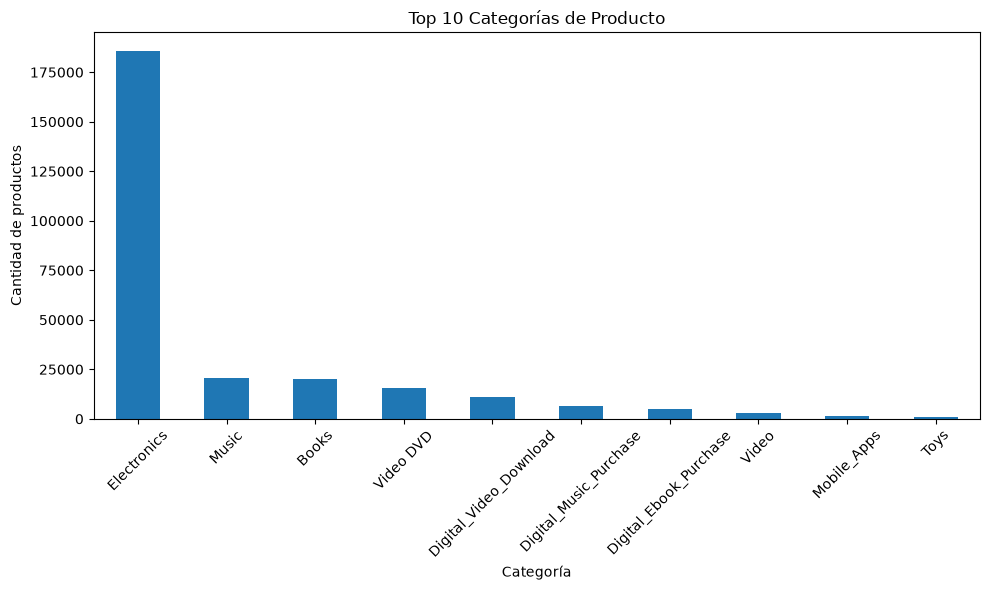

In [377]:
plt.figure(figsize=(10,6))
df_productos["product_category"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Categorías de Producto")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de productos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esta sección podemos observar un gráfico de barras en el cual se ve que Electronicos es el producto dominante del cuál más compran los consumidores. Tambien se puede visualizar los otros tipos de productos que vende Amazon, con una cantidad muy mínima como Juguetes.

6.6 Cruce: longitud de reseña vs. calificación

   star_rating  promedio_caracteres  promedio_palabras  total_reseñas
0            1           405.784519          73.862709           7648
1            2           529.502180          95.516347           4588
2            3           518.522301          93.512605           7735
3            4           462.436473          83.086081          18134
4            5           330.225802          59.586073          61895


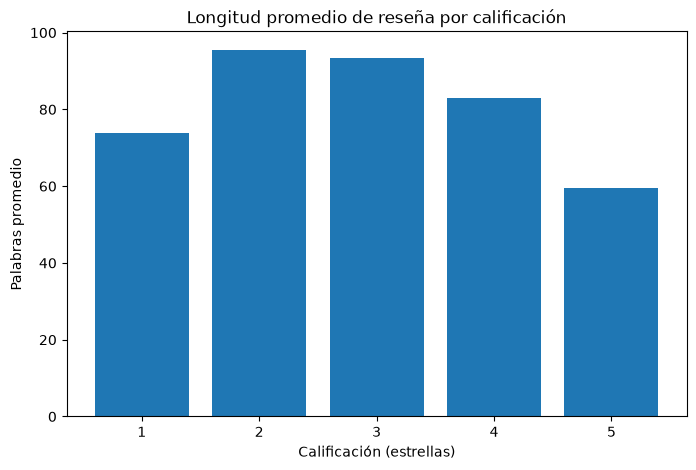

In [378]:
df_reviews_completo = pd.merge(df_reviews, df_reviews_texto, on='review_id', how='inner')

longitud_por_calificacion = df_reviews_completo.groupby('star_rating').agg(
    promedio_caracteres=('body_length_chars', 'mean'),
    promedio_palabras=('body_length_words', 'mean'),
    total_reseñas=('review_id', 'count')
).reset_index()

print(longitud_por_calificacion)

plt.figure(figsize=(8,5))
plt.bar(longitud_por_calificacion['star_rating'], longitud_por_calificacion['promedio_palabras'])
plt.title("Longitud promedio de reseña por calificación")
plt.xlabel("Calificación (estrellas)")
plt.ylabel("Palabras promedio")
plt.show()

Esta es una información interesante de observar ya que las barras 2 y 3 presentan los comentarios más largos por reseña, mientras que la calificación 5 presenta lo longitud promedio más baja de reseñas. Esto influye mucho en como se comporta el consumidor con una calificación de 1,2,3 estrellas el usuario toma mas tiempo para explicar de forma detallada sobre su insadisfacción hacia el producto en cambio una reseña de 5 estrellas el usuario toma menos tiempo y escribe un comentario breve. 



6.7 Análisis de sentimiento del texto (NLP)

In [379]:
def obtener_sentimiento_polaridad(texto):
    return TextBlob(texto).sentiment.polarity

df_reviews_texto['polaridad'] = df_reviews_texto['review_body'].apply(obtener_sentimiento_polaridad)

def clasificar_polaridad(p):
    if p > 0.1:
        return 'positivo'
    elif p < -0.1:
        return 'negativo'
    else:
        return 'neutral'

df_reviews_texto['sentimiento_texto'] = df_reviews_texto['polaridad'].apply(clasificar_polaridad)
print(df_reviews_texto['sentimiento_texto'].value_counts())

sentimiento_texto
positivo    74441
neutral     19973
negativo     5586
Name: count, dtype: int64


Al analizar el sentimiento a partir del contenido real del texto (review_body) usando TextBlob, se observa que 74441 reseñas son positivas, 19973 son neutrales y 5586 negativas. Al comparar esto con la clasificación de sentimiento que se encuentra en la Fase 8.1 basada en star_rating 80029 positivas, 12236 negativas y 7735 neutrales se nota que el análisis del texto detecta considerablemente menos reseñas negativas y más reseñas neutrales. Se podría decir que es posible que algunos clientes otorguen una calificación baja debido a un problema que tuvieron ya sea por cuestión de tiempo de envío, retraso entrega tardía sin que se expresa negativamente sino más bien como una respuesta neutral en lugar de una queja grave.

6.8 Comparación: sentimiento por estrellas vs. sentimiento por texto

In [380]:
def clasificar_sentimiento(rating):
    if rating >= 4:
        return 'positivo'
    elif rating <= 2:
        return 'negativo'
    else:
        return 'neutral'

df_reviews['sentimiento'] = df_reviews['star_rating'].apply(clasificar_sentimiento)

In [381]:
df_comparacion = pd.merge(df_reviews[['review_id', 'sentimiento']], 
                            df_reviews_texto[['review_id', 'sentimiento_texto']], 
                            on='review_id', how='inner')

coincidencias = (df_comparacion['sentimiento'] == df_comparacion['sentimiento_texto']).mean()
print(f"Coincidencia entre ambos métodos: {coincidencias:.2%}")

Coincidencia entre ambos métodos: 70.80%



Esta comparación indica que existe un 70.80% de coincidencia entre el método de sentimiento basado en el número de estrellas (rating) y el sentimiento_texto, que se basa en las palabras que el cliente escribió. Esto sugiere que en este caso ambos métodos reflejan una experiencia similar aunque el 29.2% restante de discrepancia indica que existe un grupo de reseñas donde la calificación numérica y el lenguaje utilizado no coinciden completamente.

6.9 Matriz de correlación

                  star_rating  helpful_votes  total_votes  helpful_ratio  \
star_rating          1.000000      -0.049165    -0.100052      -0.098841   
helpful_votes       -0.049165       1.000000     0.970006       0.178761   
total_votes         -0.100052       0.970006     1.000000       0.164683   
helpful_ratio       -0.098841       0.178761     0.164683       1.000000   
verified_numeric     0.072874      -0.069748    -0.094644      -0.192788   

                  verified_numeric  
star_rating               0.072874  
helpful_votes            -0.069748  
total_votes              -0.094644  
helpful_ratio            -0.192788  
verified_numeric          1.000000  


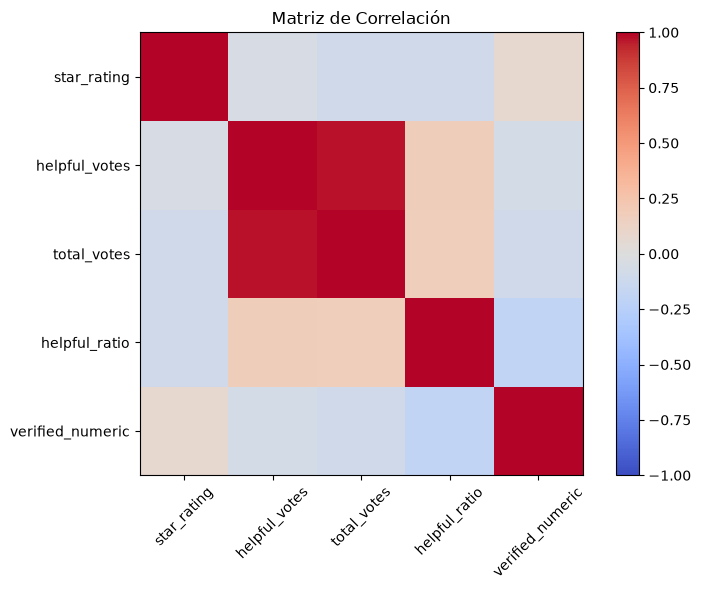

In [382]:
variables_numericas = df_reviews[['star_rating', 'helpful_votes', 'total_votes', 'helpful_ratio', 'verified_numeric']]
correlacion = variables_numericas.corr()
print(correlacion)

plt.figure(figsize=(8,6))
plt.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

En este mapa de calor se muestra que almenos los que son votos útiles y votos totales muestran un valor de +0.9 ya que el total de votos incluye tambien a los votos útiles por lo que ambas crecen de forma conjunta,lo que seria índice de utilidad seria un proporción de 0 a 1 este indica una relación positiva pero no tan fuerte en lo que respecta a la calificación por estrellas no tiene mucha relación lineal con la cantidad de votos útiles o votos totales es decir una reseña que se considere que tengan votos útiles no depende de si el producto obtuvo una calificación de 1 o 5 estrellas. Es importante saber que el hecho de que una compra sea verificada por el cliente no tiene que ver con la calificación ni con el total de votos que tenga su reseña siendo el hallazgo más consistente de esta matriz. 

6.10 Nota sobre reseñas sin comentario

In [383]:
sin_comentario = df_reviews_texto[df_reviews_texto['tiene_comentario'] == 0]
print(f"Reseñas sin comentario: {len(sin_comentario)} de {len(df_reviews_texto)}")

df_reviews_texto['excluir_de_sentimiento'] = df_reviews_texto['tiene_comentario'] == 0

Reseñas sin comentario: 15 de 100000


Esta observación confirma que de una muestra de 100,000 reseñas, 15 no cuentan con comentario de texto por parte del usuario es decir la variable tiene_comentario es igual a 0. Por lo cual se considera que estos registros no se eliminan ni se completan artificialmente, ya que representan información real "un cliente que calificó el producto pero no comentó". Por tal razón se creó la variable excluir_de_sentimiento, que marca estos 15 casos como True, permitiendo excluirlos del análisis de sentimiento.

Conclusión Analisis Explotario EDA 

El análisis exploratorio permitió identificar patrones importantes en el comportamiento de los clientes. En primer lugar, se cuenta con calificaciones mayormente muy positivas de 5 estrellas. En el histograma de votos útiles y el de longitud de reseñas se observó una distribución sesgada, donde se verificó que la mayoría de las reseñas reciben pocos o ningún voto útil lo que indica que muy pocas personas llegan a marcar si una reseña les resultó útil, o simplemente pasa desapercibida. De igual manera, se identificó que los usuarios prefieren escribir comentarios cortos y directos, aunque existe un pequeño grupo de reseñas mucho más extensas que elevan el promedio.

Se observó también que Electronica es la categoría dominante en volumen de productos, mientras que en marcas sería TiVo. Al analizar la longitud de reseña frente a la calificación, se encontró que las calificaciones más bajas tienden a tener comentarios más largos, mientras que las calificaciones de más altas estrellas suelen ser más breves.

En cuanto al análisis de sentimiento, es posible que algunos clientes otorguen una calificación baja debido a un problema puntual como por ejemplo el tiempo de entrega. A partir del contenido del texto, se observa que 74441 reseñas son positivas, 19973 neutrales y 5586 negativas. Al comparar el sentimiento por estrellas contra el sentimiento por texto, se encontró una coincidencia del 70.80% por ejemplo 2 estrellas junto con un comentario como "Pésimo, llegó muy tarde", mientras que el 29.2% restante representa los casos donde no coinciden como una calificación de 2 estrellas con un comentario de tono neutral por ejemplo.

Respecto a la matriz de correlación, existe una correlación muy fuerte entre votos útiles y total de votos indicando que la mayor participación de usuarios tienden acumular más cantidad de votos útiles ademas de que el hecho de que una compra sea verificada por el cliente no tiene que ver con la calificación ni con el total de votos que tenga su reseña. Por último, la nota sobre reseñas sin comentario representa información sobre clientes que califican el producto pero no dejan comentario de texto.

Fase 7. Preprocesamiento antes de modelar 

7.1 Codificación por frecuencia

In [384]:
frecuencia_categoria = df_reviews_productos['product_category'].value_counts(normalize=True)
df_reviews_productos['categoria_frecuencia'] = df_reviews_productos['product_category'].map(frecuencia_categoria)

print(df_reviews_productos[['product_category', 'categoria_frecuencia']].head(10))



  product_category  categoria_frecuencia
0      Mobile_Apps               0.14693
1      Electronics               0.30881
2        Video DVD               0.10881
3      Electronics               0.30881
4            Books               0.08409
5      Mobile_Apps               0.14693
6             Toys               0.00577
7      Mobile_Apps               0.14693
8      Electronics               0.30881
9      Mobile_Apps               0.14693


Se realizo la Codificación por frecuencia para product_category con el fin de mantener el proceso más rápido y ligero. El objetivo de este método es reemplazar cada categoría por su frecuencia lo que genera una única columna numerica y permite presentar que tan común es cada categoría sin aumentar la dimensionalidad de los datos. 

7.2 Transformación logarítmica de Votos Totales y Votos Útiles

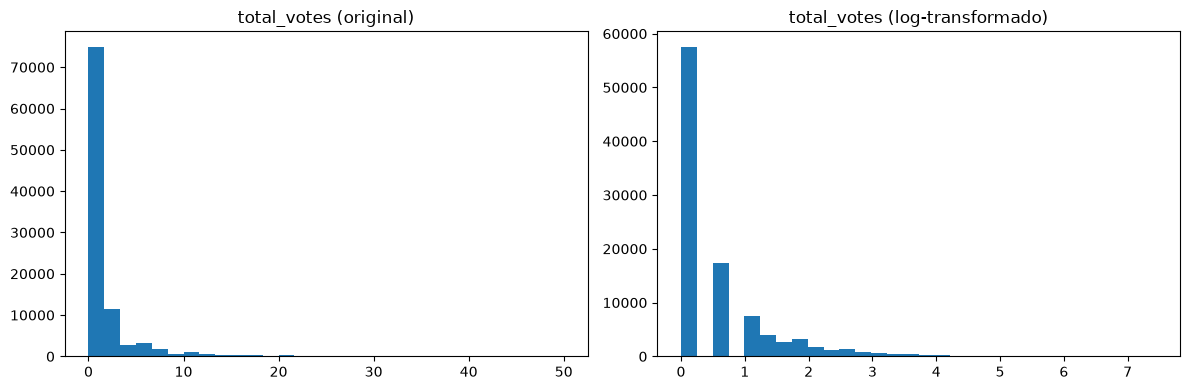

In [385]:
df_reviews['total_votes_log'] = np.log1p(df_reviews['total_votes'])
df_reviews['helpful_votes_log'] = np.log1p(df_reviews['helpful_votes'])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_reviews['total_votes'], bins=30, range=(0,50))
plt.title("total_votes (original)")

plt.subplot(1,2,2)
plt.hist(df_reviews['total_votes_log'], bins=30)
plt.title("total_votes (log-transformado)")

plt.tight_layout()
plt.show()

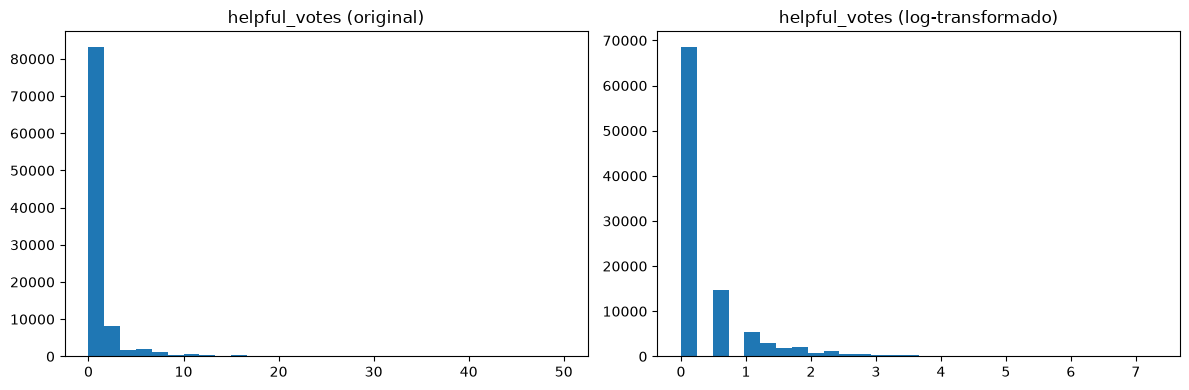

In [386]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_reviews['helpful_votes'], bins=30, range=(0,50))
plt.title("helpful_votes (original)")

plt.subplot(1,2,2)
plt.hist(df_reviews['helpful_votes_log'], bins=30)
plt.title("helpful_votes (log-transformado)")

plt.tight_layout()
plt.show()

Se aplicó la transformación logarítmica (log1p) para ambas variables total_votes y helpful_votes con el objetivo de reducir el impacto de los valores atípicos, se puede observar que paso de tener una barra muy alta con una fuerte caída a tener una distribución más escalonada, eso no quiere decir que se eliminaron los valores atípicos sino más bien que no lo dominen y que el modelo sea mas equilibrado. 

Conclusión del Preprocesamientoa antes de Modelar 

Para hacer el Modelo de Machine learning fue necesario aplicar la Codificación por frecuencia. Este método reemplaza cada categoría de texto (product_category) según que tan frecuente es, es decir va contando cuantas veces aparece, pero como la categoria de producto esta en texto fue necesario cambiarlo a numérico para que el Machine learning lo pudiera leer y al mismo tiempo se crea solo 1 columna volviendolo mas ligero y fácil de analizar.

Se aplicó la transformación logarítmica (log1p) con el objetivo de no eliminar los datos atipicos sino mas bien comprimir esos datos grandes o extremos que se ven para que no dominen el modelo, de esta forma solo cambia como se ven sin afectar nada más pero la información real sigue estando ahí.

Fase 8. Construcción y Evaluación del Modelo Maching Learning (Random Forest)

 8.1 Crear la variable a predecir (sentimiento)

In [387]:
print(df_reviews['sentimiento'].value_counts())

sentimiento
positivo    80029
negativo    12236
neutral      7735
Name: count, dtype: int64


Se muestra nuevamente el conteo de reseñas por categoría de sentimiento creada previamente en la sección 6.8, con el fin de tenerlo como referencia antes de construir el modelo. Como se puede observar en el resultado, la mayoría fue el positivo, igual que se mostró en la Estadística Descriptiva, en la que se indicaba que la mayoría de las reseñas son positivas. Es importante indicar que se crea como tal esta variable para que el modelo pueda saber o aprender como se debe desarrollar a tráves de sentimientos como postivo, negativo y neutral. 

8.2 Iteración 1: Modelo con variables de comportamiento

In [388]:
features_v1 = ['helpful_votes_log', 'total_votes_log', 'helpful_ratio', 
               'verified_numeric', 'vine_numeric', 'es_voto_anomalo']

X_v1 = df_reviews[features_v1]
y_v1 = df_reviews['sentimiento']

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.2, random_state=42, stratify=y_v1
)

modelo_v1 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_v1.fit(X_train_v1, y_train_v1)

y_pred_v1 = modelo_v1.predict(X_test_v1)
print("=== Iteración 1: Variables de comportamiento ===")
print(classification_report(y_test_v1, y_pred_v1))

=== Iteración 1: Variables de comportamiento ===
              precision    recall  f1-score   support

    negativo       0.30      0.40      0.34      2447
     neutral       0.09      0.21      0.13      1547
    positivo       0.86      0.72      0.79     16006

    accuracy                           0.64     20000
   macro avg       0.42      0.44      0.42     20000
weighted avg       0.73      0.64      0.68     20000



8.3 Iteración 2 (agregando longitud de texto)

In [389]:
df_modelo_v2 = pd.merge(df_reviews, df_reviews_texto, on='review_id', how='inner')

features_v2 = ['helpful_votes_log', 'total_votes_log', 'helpful_ratio', 
               'verified_numeric', 'vine_numeric', 'es_voto_anomalo',
               'body_length_words', 'headline_length_words']

X_v2 = df_modelo_v2[features_v2]
y_v2 = df_modelo_v2['sentimiento']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

modelo_v2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = modelo_v2.predict(X_test_v2)
print("=== Iteración 2: + Longitud de texto ===")
print(classification_report(y_test_v2, y_pred_v2))

=== Iteración 2: + Longitud de texto ===
              precision    recall  f1-score   support

    negativo       0.26      0.38      0.31      2447
     neutral       0.09      0.22      0.13      1547
    positivo       0.85      0.66      0.74     16006

    accuracy                           0.60     20000
   macro avg       0.40      0.42      0.39     20000
weighted avg       0.72      0.60      0.64     20000



En la parte 8.2 Iteración 1: Modelo con variables de comportamiento se ve que el accuracy es de 64% teniendo un recall negativo de 0.40 mientras que el la Interación 2 (Agregando longitud de texto ) es de 60% teniendo un recall negativo de 0.38. El primero modelo inicial sobresale con las reseñas positivas siendo esta mucho mayor que la negativa y el segundo modelo esta mucho peor en ese sentido lo cuál indica que la longitud del comentario no realiza una buena predicción del sentimiento, ya que una reseña larga puede indicar tanto una opinión positiva como negativa. Con base a lo anterior, se decidió descartar esta variable y se buscó una otra forma que es incorporar el sentimiento real del texto mediante Análisis de Polaridad, lo cual se desarrolla a continuación en el modelo final.

8.4 Modelo Final: Incorporando polaridad del texto

In [390]:
df_modelo_final = pd.merge(df_reviews, df_reviews_texto[['review_id', 'polaridad']], on='review_id', how='inner')

features = ['helpful_votes_log', 'total_votes_log', 'helpful_ratio', 
            'verified_numeric', 'vine_numeric', 'es_voto_anomalo', 
            'polaridad']

X = df_modelo_final[features]
y = df_modelo_final['sentimiento']

print(X.head())
print(f"\nTotal de filas para el modelo: {X.shape[0]}")

   helpful_votes_log  total_votes_log  helpful_ratio  verified_numeric  \
0           0.000000         0.000000            0.0                 1   
1           0.693147         0.693147            1.0                 1   
2           0.000000         0.000000            0.0                 1   
3           0.000000         0.000000            0.0                 1   
4           0.000000         0.000000            0.0                 0   

   vine_numeric  es_voto_anomalo  polaridad  
0             0            False   0.575000  
1             0            False   0.507500  
2             0            False   0.500000  
3             0            False   0.121250  
4             0            False   0.086301  

Total de filas para el modelo: 100000


Para construir el modelo final, se unieron las tablas df_reviews y df_reviews_texto mediante review_id, se incorporo la variable polaridad  obtenida del análisis de sentimiento del texto realizado antes en las pruebas de arriba junto con algunas variables de comportamiento ya trabajadas como: votos, verificación, anomalías. Tambien se definio 7 variables denominadas features que ayudan a la construcción del modelo. Además se estableció sentimiento como la variable objetivo a predecir tomando en cuenta tanto el comportamiento de la reseña como el contenido real expresado por el cliente.

8.5 Dividir train/test

In [391]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 80000 filas
Prueba: 20000 filas


En esta parte se realiza la división del conjunto de datos en dos partes, 80000 filas para entrenamiento y 20000 filas para prueba. Esto permite que el modelo aprenda los patrones únicamente con los datos de entrenamiento, y que su desempeño se evalúe después con los datos de prueba que no vio durante el aprendizaje. De esta manera, se obtiene una evaluación más realista de su capacidad predictiva.

8.6 Entrenar Random Forest

In [392]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


Se entrena el modelo Random Forest utilizando los datos de entreno como lo son: X_train, y_train. Esto se realizo porque la mayoría de las reseñas son positivas. De esta manera  ayuda a que el modelo no ignore las categorías que tienen poco valor.

8.7 Evaluar el módelo 

In [393]:
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negativo       0.32      0.56      0.40      2447
     neutral       0.10      0.25      0.15      1547
    positivo       0.89      0.67      0.76     16006

    accuracy                           0.62     20000
   macro avg       0.44      0.49      0.44     20000
weighted avg       0.76      0.62      0.67     20000



Se evaluó el modelo con una exactitud del 62%. En base a lo que se observa solo se encuentra el 67% de las reseñas positivas reales (recall) mientras que la parte negativa solo se detecta un 56% de las reseñas negativas, lo cuál nos indica por ejemplo que de cada 100 veces que se indica negativo solo se acierta con una precisión de 32%.La parte neutral es lo más bajo que hay con una precisión de 10% y una exhaustividad de 25%. Menciono también que anteriormente había realizado un modelo inicial y otra interación que dio una exactitud de 64% y el otro de 60% el primero no estaba tan mal y segundo si estaba peor pero igual los dos no me estaban ayudando a detectar reseñas negativas como este modelo que resultó considerablemente mejor en ese aspecto, eso si lo había realizado sin la variable polaridad en esta si la aplique. Al poner la variable polaridad me ayudó a identificar mejor las experiencias negativas de los clientes y que importante puede ser valorar mas este aspecto de insatisfacción en los clientes que un modelo exacto. 

Conclusiones del Proyecto (Resultados)

Respecto a los clientes, se confirmó que no existen registros duplicados lo que garantiza que cada cliente está representado una única vez. Con base en el estudio de productos, la categoría Electronics  la categoría Electronics destaca como la más predominante por el consumidor, tanto en catálogo como en volumen de reseñas. Sin embargo, al analizar la reputación de marca por categoría, se encontró que la marca con mejor promedio de todo el top 10 fue TiVo, dentro de la propia categoría Electronics, con un promedio de 5.00. Se refleja además una alta satisfacción general de los clientes, con un promedio de calificación de 4.22, donde predomina la puntuación máxima, aunque persiste un sector crítico de usuarios con calificaciones de 1 o 2 estrellas.

En cuanto al comportamiento de las reseñas, la mayoría no recibe votos de utilidad, mientras que un pequeño grupo concentra una cantidad desproporcionada de votos, posiblemente por tratarse de reseñas destacadas o promovidas por Amazon. De igual manera, los usuarios prefieren escribir comentarios cortos y directos, aunque existe un pequeño grupo de reseñas mucho más extensas. Se identificó también que las calificaciones más bajas tienden a tener comentarios más largos, mientras que las de 5 estrellas suelen ser más breves, y que 500 reseñas (0.5%) presentaron un comportamiento de votación fuera de lo normal, además de 8849 calificaciones (8.85%) consideradas anómalas respecto al comportamiento típico de su categoría.

Sobre el análisis de sentimiento, al comparar el sentimiento por estrellas contra el sentimiento por texto (TextBlob), se encontró una coincidencia del 70.80%, lo que indica que, en la mayoría de los casos, ambos métodos reflejan una experiencia similar, aunque el 29.2% restante muestra casos donde la calificación numérica y el lenguaje utilizado no coinciden completamente. Asimismo, se confirmó que una compra verificada no muestra una relación lineal con la calificación ni con los votos.

Como parte del construcción y evaluación del Modelo Maching Learning se decidió construir mediante el modelo llamado Random Forest ya que tenemos varios datos atípicos que no se eliminaron porque se considero que es información relevante para el estudio y aplique una transformación logarítmica (log1p) para conservar la información y reducir de este modo el impacto de los datos atípicos. Considero importante mencionar que en el desarrollo de preprocesamiento no se realizo una estandarización o normalización ya que Random Forest puede funcionar bien sin afectar nada. 

Finalmente, en el modelo Random Forest, se evaluó dos versiones, primero una versión inicial y otra interación más sin la variable polaridad, que obtuvo una exactitud del 64% y otra del 60% pero con menor capacidad de detectar reseñas negativas. Al incorporar la polaridad del texto, el modelo final alcanzó una exactitud del 62%, con una mejora considerable en la detección de reseñas negativas (56% de recall). Esto permitió identificar mejor las experiencias negativas de los clientes, demostrando que puede ser más importante valorar el aspecto de insatisfacción y quejas que una exactitud alta en el modelo.

Conclusion Personal sobre el proyecto

A modo de conclusión sobre el proyecto en general, me parecio muy interesante investigar e integrar conocimientos que se han tocado durante el curso. En primera instancia se van viendo datos que a medida que avanzas vas pensando en los analices del comercio electronico en Amazon como por ejemplo como los clientes con calificaciones altas prefieren escribir mensajes cortos, mientras que en los negativos con bajas calificaciones los clientes suelen mas escribir mensajes mas extensos para explicar una situación ya sea del envio o del producto que no les gustó y esto es de vital para tener puntos de mejora del que esta pasando y minimizas esos comentarios, es decir nos permiten saber como se comporta el consumidor y las interacciones que van teniendo, aun siendo dificil detectar a traves del texto ya sean positivos, negativos o neutrales los sentimientos de los usuarios. Y a medida que se analiza tambien se van tomando decisiones como en este caso se trabajo con muestras en las reseñas porque los datos consumian mucho almacenamiento y se iba a quedar muy pecado a como en el procesamiento tambien se tomó la decisión de como proceder porque mucha limpieza se habia hecho en SQL entonces como trabajar y modelar con los datos que tengo, de si este sera el mejor modelo o trabajo con otro y si creo mas versiones para ver si llevo a ese resultado quizas un poco mas exacto. A nivel personal de Ciencia de Datos me enseña que son decisiones basadas en como quieres presentar ese analices y con lo que tienes como presentar esa idea del negocio. 